# 04 · Forward in time on CSE-CIC-IDS2018

**Question.** Does detection hold up for the same attack on a later date, the same attack family
with a new tool, and a brand-new family?

2018 repeats some attack families on later days, so it can ask three different questions that
2017 cannot. Every fold trains on all days before the test day. Thresholds are frozen at a 1%
budget on validation benign flows: a 20% holdout of the training days for the "same attack" and
"new tool" folds, and the previous day for the "new family" fold.

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")  # make src/ importable from notebooks/
warnings.filterwarnings("ignore", message="X does not have valid feature names")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.reporting.plots import load_summary, recall_dots, recall_table, style, COLORS, NAMES, INK, MUTED
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)
REPORTS = "../reports"
summary = load_summary()

def finding(folds, labels=None, caveats=None):
    for f in folds:
        d = summary["folds"][f]
        quotable = {n: v["budgets"]["0.01"]["recall"]["median"]
                    for n, v in d["detectors"].items() if not v["budget_violated"]["0.01"]}
        broke = [NAMES[n] for n, v in d["detectors"].items() if v["budget_violated"]["0.01"]]
        # ties go to the single model (a hybrid that gave one model the whole budget is that model)
        best = max(quotable, key=lambda n: (quotable[n], "+" not in n)) if quotable else None
        line = f"{(labels or {}).get(f, f)}: "
        if d["unseen_test_families"]:
            line += f"unseen families {', '.join(d['unseen_test_families'])}. "
        line += (f"Best detector within its false-alarm budget: {NAMES[best]}, recall {quotable[best]:.1%} "
                 f"(median of {len(d['seeds'])} seeds)" if best else "No detector stayed within its false-alarm budget")
        if broke:
            line += f". Over budget (recall not quotable): {', '.join(broke)}"
        if best and d["detectors"][best].get("shortcut_flag"):
            line += f". Shortcut flag: one feature ({', '.join(d['best_single_feature'])}) comes within 0.05 AP of it"
        if (caveats or {}).get(f):
            line += f". CAVEAT: {caveats[f]}"
        print(line + ".")

LABELS_2018 = {'2018_new_tool_dos': 'Same family, new tool: DoS (16 Feb)', '2018_new_tool_ddos': 'Same family, new tool: DDoS (21 Feb)', '2018_same_attack_web': 'Same attack, later date: web (23 Feb)', '2018_same_attack_infiltration': 'Same attack, later date: infiltration (1 Mar)', '2018_new_family_bot': 'New family: Bot (2 Mar)'}
finding(list(LABELS_2018), LABELS_2018)


Same family, new tool: DoS (16 Feb): Best detector within its false-alarm budget: Logistic regression, recall 100.0% (median of 5 seeds). Over budget (recall not quotable): Isolation Forest, Autoencoder, LightGBM, Hybrid: LightGBM + anomaly model, Hybrid: log. regression + anomaly model. Shortcut flag: one feature (Destination Port) comes within 0.05 AP of it.
Same family, new tool: DDoS (21 Feb): Best detector within its false-alarm budget: Logistic regression, recall 82.2% (median of 5 seeds). Shortcut flag: one feature (Fwd Packet Length Max, Fwd Packet Length Mean, Total Fwd Packets) comes within 0.05 AP of it.
Same attack, later date: web (23 Feb): Best detector within its false-alarm budget: LightGBM, recall 72.3% (median of 5 seeds).
Same attack, later date: infiltration (1 Mar): Best detector within its false-alarm budget: Logistic regression, recall 1.7% (median of 5 seeds). Over budget (recall not quotable): Isolation Forest, Autoencoder, LightGBM, Hybrid: LightGBM + anomaly 

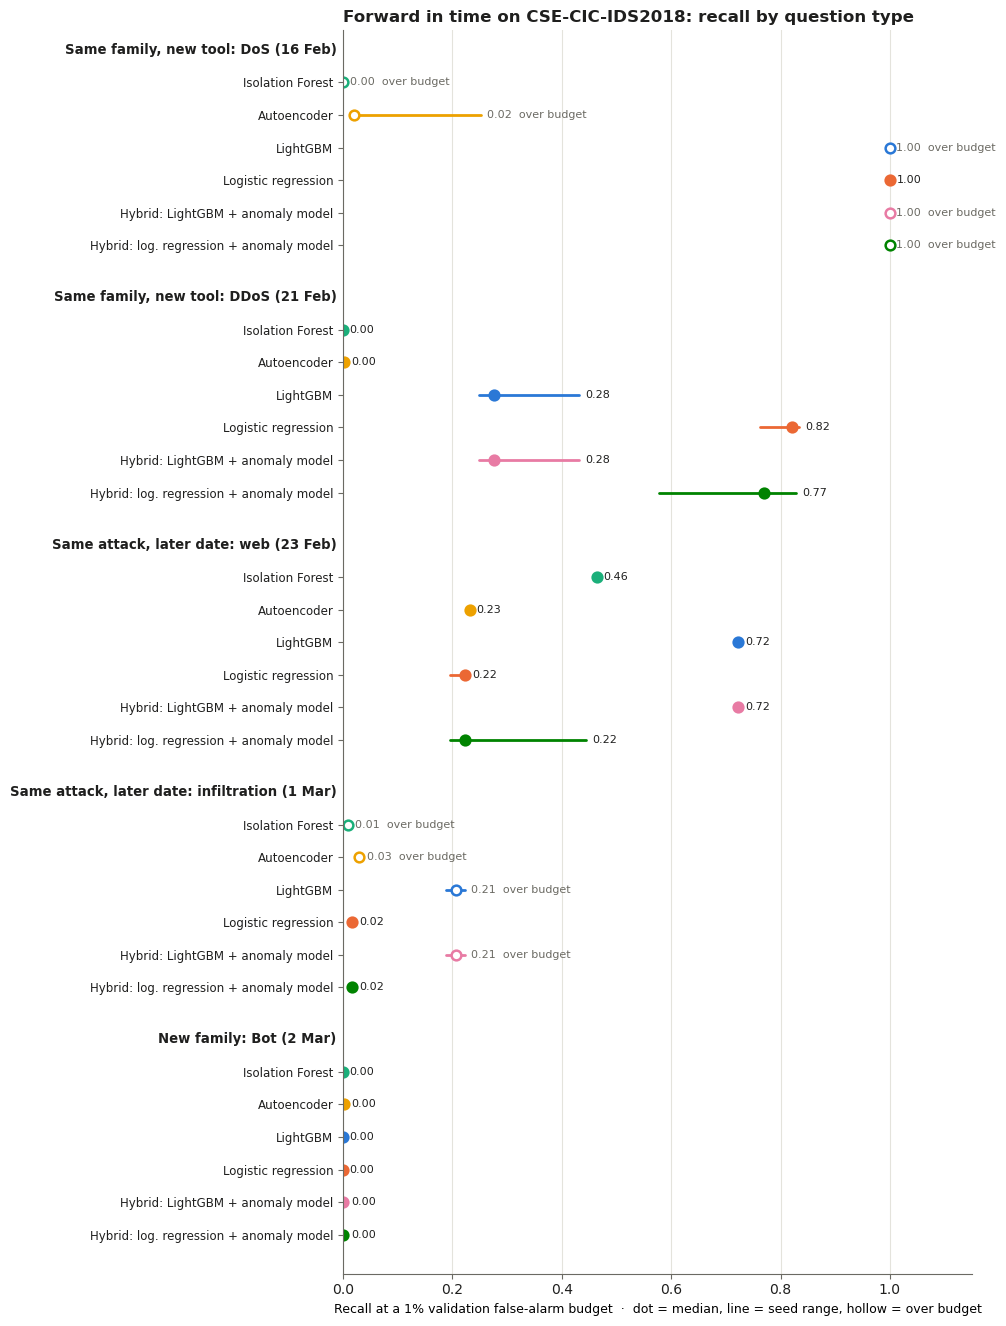

,fold,question,detector,recall (median),recall range,actual FPR range,AP (median),ROC AUC (median),prevalence
0,2018_new_tool_dos,"same family, new tool",Isolation Forest,0.000,0.000-0.000,0.0051-0.0160,0.384,0.005,0.5747
1,2018_new_tool_dos,"same family, new tool",Autoencoder,0.021,0.019-0.251,0.1483-0.9924,0.422,0.140,0.5747
2,2018_new_tool_dos,"same family, new tool",LightGBM,1.000,1.000-1.000,0.8220-0.9943,1.000,1.000,0.5747
3,2018_new_tool_dos,"same family, new tool",Logistic regression,1.000,1.000-1.000,0.0003-0.0003,1.000,1.000,0.5747
4,2018_new_tool_dos,"same family, new tool",Hybrid: LightGBM + anomaly model,1.000,1.000-1.000,0.8220-0.9943,NaN,NaN,0.5747
5,2018_new_tool_dos,"same family, new tool",Hybrid: log. regression + anomaly model,1.000,1.000-1.000,0.0003-0.6154,NaN,NaN,0.5747
6,2018_new_tool_ddos,"same family, new tool",Isolation Forest,0.000,0.000-0.000,0.0010-0.0010,0.455,0.003,0.6546
7,2018_new_tool_ddos,"same family, new tool",Autoencoder,0.003,0.003-0.003,0.0032-0.0056,0.442,0.003,0.6546
8,2018_new_tool_ddos,"same family, new tool",LightGBM,0.276,0.248-0.432,0.0002-0.0002,0.866,0.640,0.6546
9,2018_new_tool_ddos,"same family, new tool",Logistic regression,0.822,0.763-0.834,0.0002-0.0002,0.999,1.000,0.6546


In [2]:
FOLDS = ['2018_new_tool_dos', '2018_new_tool_ddos', '2018_same_attack_web', '2018_same_attack_infiltration', '2018_new_family_bot']
LABELS = {'2018_new_tool_dos': 'Same family, new tool: DoS (16 Feb)', '2018_new_tool_ddos': 'Same family, new tool: DDoS (21 Feb)', '2018_same_attack_web': 'Same attack, later date: web (23 Feb)', '2018_same_attack_infiltration': 'Same attack, later date: infiltration (1 Mar)', '2018_new_family_bot': 'New family: Bot (2 Mar)'}
fig = recall_dots(summary, FOLDS, 'Forward in time on CSE-CIC-IDS2018: recall by question type', LABELS)
plt.show()
recall_table(summary, FOLDS)

In [3]:
# Recall per attack family at the 1% budget (median over seeds, n = flows in the test set)
rows = {}
for f in FOLDS:
    fold = summary["folds"][f]
    for det, d in fold["detectors"].items():
        for fam, r in d["per_family_recall_at_1pct"].items():
            rows.setdefault((LABELS[f], fam), {})[NAMES[det]] = round(r["median"], 3)
pd.DataFrame(rows).T

,,Isolation Forest,Autoencoder,LightGBM,Logistic regression,Hybrid: LightGBM + anomaly model,Hybrid: log. regression + anomaly model
"Same family, new tool: DoS (16 Feb)",DoS,0.000,0.021,1.000,1.000,1.000,1.000
"Same family, new tool: DDoS (21 Feb)",DDoS,0.000,0.003,0.276,0.822,0.276,0.769
"Same attack, later date: web (23 Feb)",Web attack,0.465,0.231,0.723,0.223,0.723,0.223
"Same attack, later date: infiltration (1 Mar)",Infiltration,0.009,0.029,0.206,0.017,0.206,0.017
New family: Bot (2 Mar),Bot,0.000,0.002,0.000,0.000,0.000,0.001


## What this shows

- **Same attack, later date: one clean success, one failure.** The web attacks of 22 Feb return on
  23 Feb, and LightGBM catches most of them within its budget, with no single-feature shortcut.
  This is the most trustworthy positive result in the project. Infiltration, which also repeats,
  is not caught: LightGBM's frozen threshold lets through 13-17% of benign flows on the new day,
  and logistic regression stays in budget but catches almost nothing.
- **Same family, new tool: caught, but through shortcuts.** Logistic regression catches the new DoS
  and DDoS tools within budget, but one feature alone (destination port for DoS; forward packet
  length for DDoS) reaches AP 0.999. On the DoS day, 23% of test attack flows are exact copies of
  flows from the training days: flood traffic repeats byte for byte. These are not evidence of
  learning what DoS is.
- **New family: nothing works.** Bot on 2 Mar is caught by no detector, at any seed.
- **Frozen thresholds drift.** On the DoS day, LightGBM's "1%" threshold flags 82-99% of benign
  flows. A threshold chosen on earlier days is not safe on a new day without recalibration.

## Limits

2018's benign flows are a 10% sample (prevalence-weighted). The web folds have only a few hundred
attack flows, so their per-family intervals are wide (see the results file).